


# Path Specifications and Ensemble Definition

---

This script loads data from COSMO-SPECS simulations and generates a quicklook of ice and water mass in several dimensions.

    - profile
    - timeseries
    - area
    - single spectra
    - path

In [3]:
%matplotlib inline
import subprocess
import os
import sys
import glob
import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np
import random
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.dates as md
import importlib
import pandas as pd
import seaborn as sns

import colormaps as cmaps

import utilities.tools as tools
importlib.reload(tools) # to avoid restarting the kernel



<module 'utilities.tools' from '/home/b/b382237/code/polarcap/python/utilities/tools.py'>

In [ ]:
data_path = '/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x42x100/'
obs_path = '../data_obs'
plot_path = '../plots'

tshift = 'no'

#data_set = 'cs-eriswil__20240711_153416' # ishape=1 VERY old run
#data_set = 'cs-eriswil__20250304_140529' # fluxes (NO nf,nw,qf,qw) (ishape=1) AR=10,d (ishape=3) AR=empirical fcn, (ishape=4) AR=empirical fcn
#data_set = 'cs-eriswil__20250306_125823' # fluxes (nf,nw,qf,qw) (ishape=4) AR=empirical fcn

# ensembles with variing BG INP/CCN and flare INP/CCN
#data_set = 'cs-eriswil__20250219_100953' # even larger ensemble
#data_set = 'cs-eriswil__20250219_223004' # even larger ensemble  varying flare inp

# high time resolution data
#data_set, resolution = 'cs-eriswil__20250117_111628', 'yes' # 200x160 5sec output
#data_set, resolution = 'cs-eriswil__20250309_154959', 'yes' # 5sec 12utc 
data_set, resolution = 'cs-eriswil__20250318_234102', 'no' # 5sec 09utc 
data_set, resolution = 'cs-eriswil__20250318_154251', 'yes' # 5sec 12utc 

data_set, resolution = 'cs-eriswil__20251125_114053', 'yes'
#    "cs-eriswil__20250520_144435/3D_20250520144435.nc",
#    "cs-eriswil__20250520_144435/3D_20250520144545.nc",
#    "cs-eriswil__20250520_144435/3D_20250520144635.nc"

# cloudlab data 
holimo_filename             = f'{obs_path}/holimo/2023-01-25/CL_20230125_1000_1140_SM058_SM060_ts1.nc'

# LACROS raw datafiles
radar_mbr7_filespath        = f'{obs_path}/mbr7/20230125/'
mwr_data_path               = f'{obs_path}/hatpro_lacros/20230125/'

# cloudnet data
mwr_hatpro_filename_cndp    = f'{obs_path}/cloudnet_dataportal/20230125/20230125_eriswil_hatpro.nc'
radar_mira35_filename_cndp  = f'{obs_path}/cloudnet_dataportal/20230125/20230125_eriswil_mira_c98b69a5.nc'
categorize_filename_cndp    = f'{obs_path}/cloudnet_dataportal/20230125/20230125_eriswil_categorize-voodoo.nc'
iwc_filename_cndp           = f'{obs_path}/cloudnet_dataportal/20230125/20230125_eriswil_iwc-Z-T-method.nc'
lwc_filename_cndp           = f'{obs_path}/cloudnet_dataportal/20230125/20230125_eriswil_lwc-scaled-adiabatic.nc'
class_filename_cndp         = f'{obs_path}/cloudnet_dataportal/20230125/20230125_eriswil_classification-voodoo.nc'



eriswil_height_asl = 921.0

idx_run = 0

time_frame_tbs = [
    [np.datetime64('2023-01-25T10:30:00'), np.datetime64('2023-01-25T10:42:00')],
    [np.datetime64('2023-01-25T10:55:00'), np.datetime64('2023-01-25T11:07:00')],
    [np.datetime64('2023-01-25T11:20:00'), np.datetime64('2023-01-25T11:31:00')]
    ] # standart plume time frames

# time_frames_plume = [
#     [np.datetime64('2023-01-25T09:00:00'), np.datetime64('2023-01-25T09:12:00')],
#     [np.datetime64('2023-01-25T09:25:00'), np.datetime64('2023-01-25T09:37:00')],
#     [np.datetime64('2023-01-25T09:48:00'), np.datetime64('2023-01-25T10:00:00')]
#     ] # early plume time frames for testing

data_set, resolution = 'cs-eriswil__20250520_144435', 'yes'
#    "cs-eriswil__20250520_144435/3D_20250520144435.nc",
plot_time_frame = time_frame_tbs
plot_height_frame = (950, 1500)

# Import Metadata and Coordinates

In [13]:
# import utils.namelist_metadata as nm
# from utils.namelist_metadata import convert_meteogram_to_3d_data_key as convert
# from utils.namelist_metadata import ALL_ENV_VARIABLE_ATTRS as aeva
# from utils.namelist_metadata import ALL_BULK_VARIABLE_ATTRS as abva
# from utils.namelist_metadata import ALL_SPECTRAL_VARIABLE_ATTRS as asva
# from utils.namelist_metadata import tendency_attrs_3D_net as tav
# from utils.namelist_metadata import tendency_attrs_3D_pos as tavp
# from utils.namelist_metadata import tendency_attrs_3D_neg as tavn
import json

# returns a nested dict with metadata

model_data_path = f'/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/RUN_ERISWILL_50x42x100/ensemble_output/cs-eriswil__20251125_114053/'
print("\n[1] INPUT_ORG namelist file")
metadata_file = glob.glob(model_data_path + "*.json")[0]
with open(metadata_file, "r") as jsonfile: 
    metadata = json.load(jsonfile)


metadata


[1] INPUT_ORG namelist file


{'20251125114053': {'run_start_time': '1764067253',
  'job_id': '20948985',
  'nodeX': 'l20694',
  'domain': '50x40xZ',
  'INPUT_ORG': {'lmgrid': {'startlat_tot': -0.064,
    'startlon_tot': -0.084,
    'pollat': 42.93,
    'pollon': -172.127,
    'dlon': 0.004,
    'dlat': 0.004,
    'ie_tot': 42,
    'je_tot': 32,
    'ke_tot': 100},
   'sbm_par': {'ishape': 1,
    'lsbm': True,
    'iimfr': 13,
    'ifrier': 1,
    'idepo': 1,
    'imelt': 1,
    'ikofr': 1,
    'ibrea': 1,
    'ikoll': 2,
    'iice': 1,
    'iinsol': 7,
    'ikeis': 1,
    'iideal': 1,
    'epsi': 0.5,
    'itimemax': 4,
    'iap': 1,
    'ihomfr': 1,
    'mpstepsmax': 1,
    'fd4_blsize': [2, 2, 4],
    'nc_output_hcomb': [1700, 3600, 10],
    'outputname': '3D_20251125114053',
    'output_groups': '1100000',
    'fd4_lbmethod': 3,
    'fd4_lbauto': True,
    'dnap_init': 400,
    'dimensions': 3,
    'imode_in': 0,
    'dn_in': [200.0, 200.5],
    'dp_in': [1e-07, 3.5e-07],
    'sig_in': [1.5, 2.45],
    'lflare'

In [14]:

resolution = '400m'
ensemble_nrs = sorted(list(metadata.keys()))
meteogram_data_path = os.path.join(data_path, data_set, 'processed')

In [ ]:

# Create CDO rename string dynamically from metadata
spack_cdo_cmd = "/sw/spack-levante/cdo-2.5.1-vrhrix/bin/cdo"
cdo_cmd = f"{spack_cdo_cmd} -chname," + ",".join([
    *[f"{var.upper()},{var}"                for var_dict in [aeva, abva, asva] for var in var_dict],
    *[f"{key},{tendency_key}"               for key in tav if key.startswith("SUM_") for tendency_key, _ in [convert(key)]],
    *[f"SUM_P_{key[4:]},{tendency_key}_p"   for key in tavp if key.startswith("SUM_") for tendency_key, _ in [convert(key)]],
    *[f"SUM_N_{key[4:]},{tendency_key}_n"   for key in tavn if key.startswith("SUM_") for tendency_key, _ in [convert(key)]]
])

# Function to check if cdo is available
def is_cdo_available():
    return subprocess.call(['which', 'cdo'], stdout=subprocess.PIPE, stderr=subprocess.PIPE) == 0

# Attempt to run cdo command
def run_cdo_command():
    try:
        subprocess.run(cdo_cmd + f" {file_name_M} {file_name_3D_processed}", shell=True, check=True)
    except Exception as e:
        print(f"Error converting {file_name_M}: {e}")

#
model_radius = tools.define_bin_boundaries()
model_diameter_µm_bounds = model_radius * 1.0e6 * 2.0 # r[m] * m2µm(10^6) * r2d(2.0)
model_diameter_µm = (model_diameter_µm_bounds[1:] + model_diameter_µm_bounds[:-1]) / 2.0 # bin centers or midpoints (Nbins-1)


model_data = {}
for id in metadata.keys():
    file_name_3D_processed = os.path.join(meteogram_data_path, id, f'3D_{id}_meteogram_v3.nc')
    file_name_M = os.path.join(meteogram_data_path, id, f'M_00_{id}.nc')
    
    if os.path.exists(file_name_3D_processed):
        model_data[id] = xr.open_dataset(file_name_3D_processed)
    elif os.path.exists(file_name_M):
        try:
            subprocess.run(f"{cdo_cmd} {file_name_M} {file_name_3D_processed}", shell=True, check=True)
            model_data[id] = xr.open_dataset(file_name_3D_processed)
        except Exception as e:
            print(f"Error converting {file_name_M}: {e}")
    else:
        try:
            model_data[id] = tools.open_3D_data(os.path.join(data_path, data_set), id)
        except Exception as e:
            ensemble_nrs.remove(id)
            print(f'Warning: Ensemble (run_id) {id} not found --> skipping: {e}')


# # returns 1D and 2D numpy arrays of lat and lon
meta_file = glob.glob(os.path.join(data_path, data_set, '*.json'))[0]
lat_1D, lon_1D, lat_2D, lon_2D, extpar = tools.load_grid_data(meta_file)

# get time, height, radius from one ensemble
run_id = ensemble_nrs[idx_run]
model_time = model_data[run_id].time.values 
try:
    model_height = model_data[run_id].z.values
except:
    
    radius = tools.define_bin_boundaries()
    diameter_µm_bounds = radius * 2.0
    diameter_µm = (diameter_µm_bounds[1:] + diameter_µm_bounds[:-1]) / 2.0
    model_data[run_id] = model_data[run_id].rename({'HMLd_2': 'z', 'bins': 'bin'})
    bins_coord = np.arange(len(model_data[run_id].bin) + 1) 
    model_data[run_id] = model_data[run_id].assign_coords(bins=bins_coord)
    
    model_data[run_id] = model_data[run_id].assign_coords({
        'd': ('bin', diameter_µm),
        'dbounds': ('bins', diameter_µm_bounds)
        })
    
    model_data[run_id] = model_data[run_id].assign_coords({'bins': model_diameter_µm_bounds, 
                                                           'bin': model_diameter_µm,
                                                           'dz': np.diff(model_data[run_id].HHLd.values)})
    model_height = model_data[run_id].z.values



factor = 1.0e6
# # # some modifications to the model data
# # # if 'eriswil__20250117_111628' in data_set:
# # #     factor = 1.0e9
# # # if 'eriswil__20250309_154959' in data_set:
# # #     factor = 1.0e9


if True:
    time_shift = tools.get_time_shift(metadata[run_id])
    print(f'time shift: {time_shift}')
    model_data = tools.adjust_time_for_later_run_starts(model_data, time_shift)

    


In [85]:
metadata[run_id]

{'run_start_time': '1742308971',
 'job_id': '15926824',
 'nodeX': 'l[40015-40036,40038-40045]',
 'domain': '200x160xZ',
 'INPUT_ORG': {'lmgrid': {'startlat_tot': -0.076,
   'startlon_tot': -0.096,
   'pollat': 42.93,
   'pollon': -172.127,
   'dlon': 0.001,
   'dlat': 0.001,
   'ie_tot': 192,
   'je_tot': 152,
   'ke_tot': 100,
   'origin_lat': 47.070522,
   'origin_lon': 7.872991},
  'sbm_par': {'ishape': 4,
   'lsbm': True,
   'iimfr': 10,
   'ifrier': 1,
   'idepo': 0,
   'imelt': 1,
   'ikofr': 1,
   'ibrea': 1,
   'ikoll': 2,
   'iice': 1,
   'iinsol': 7,
   'ikeis': 1,
   'iideal': 1,
   'epsi': 0.5,
   'itimemax': 4,
   'iap': 1,
   'ihomfr': 1,
   'mpstepsmax': 1,
   'fd4_blsize': [2, 2, 4],
   'nc_output_hcomb': [10780, 10800, 10],
   'outputname': '3D_20250318154251',
   'output_groups': '1000000',
   'fd4_lbmethod': 3,
   'fd4_lbauto': True,
   'dnap_init': 100,
   'dimensions': 3,
   'imode_in': 0,
   'dn_in': [500000000.0, 2500000.0],
   'dp_in': [1e-07, 3.5e-07],
   'sig_

In [86]:
subprocess.call(['which', 'cdo'])

which: no cdo in (/home/b/b382237/.conda/envs/pcpaper_env/bin:/home/b/b382237/.cursor-server/cli/servers/Stable-82ef0f61c01d079d1b7e5ab04d88499d5af500e0/server/bin/remote-cli:/home/b/b382237/.conda/envs/pcpaper_env/bin:/sw/spack-levante/git-lfs-2.11.0-oihcwo/bin:/sw/spack-levante/git-2.43.3-bm2hrp/bin:/sw/spack-levante/netcdf-c-4.8.1-f7hh57/bin:/sw/spack-levante/netcdf-fortran-4.5.3-pvmcx6/bin:/sw/spack-levante/eccodes-2.21.0-3ehkbb/bin:/sw/spack-levante/hdf5-1.12.1-tvymb5/bin:/sw/spack-levante/libaec-1.0.5-gij7yv/bin:/sw/spack-levante/openmpi-4.1.2-yfwe6t/bin:/sw/spack-levante/intel-oneapi-compilers-2022.0.1-an2cbq/compiler/2022.0.1/linux/lib/oclfpga/bin:/sw/spack-levante/intel-oneapi-compilers-2022.0.1-an2cbq/compiler/2022.0.1/linux/bin/intel64:/sw/spack-levante/intel-oneapi-compilers-2022.0.1-an2cbq/compiler/2022.0.1/linux/bin:/sw/bin:/sw/spack-levante/mambaforge-22.9.0-2-Linux-x86_64-kptncg/condabin:/sw/bin:/sw/spack-workplace/spack/bin:/usr/share/Modules/bin:/usr/local/bin:/usr/bi

1

# Compute Model Mean Diameters from Spectra

In [87]:

bin_slice = slice(30, 50)
#z_slice = slice(2.0, 0.8)

def slice_bins(x):
    return x.isel(bin=bin_slice)

def compute_column_integrals(y):
    return np.trapezoid(np.array(y), x=np.array(model_height[::-1]), axis=1)

_model = model_data[run_id]
model_variables_timeheight = {}
if 'nf' in _model.data_vars:
    model_variables_timeheight.update({
        'nc_timeheight':  ('nf', lambda x: slice_bins(x).sum(dim='bin').values),
        'nw_timeheight':  ('nw', lambda x: slice_bins(x).sum(dim='bin').values),
        'mdf_timeheight': ('nf', lambda x: tools.calculate_mean_diameter(slice_bins(x).values, 
                                                                         model_radius[bin_slice])),
        'mdw_timeheight': ('nw', lambda x: tools.calculate_mean_diameter(slice_bins(x).values, 
                                                                         model_radius[bin_slice])),})
if 'qf' in _model.data_vars: 
    model_variables_timeheight.update({
        'qi_timeheight':  ('qf', lambda x: slice_bins(x).sum(dim='bin').values),
        'qc_timeheight':  ('qw', lambda x: slice_bins(x).sum(dim='bin').values),})
if 'nc' in _model.data_vars:
    model_variables_timeheight.update({
        'ni_timeheight':  ('ni', lambda x: x.values),
        'nc_timeheight':  ('nc', lambda x: x.values),})
if 'qc' in _model.data_vars:
    model_variables_timeheight.update({
        'qi_timeheight':  ('qi', lambda x: x.values),
        'qc_timeheight':  ('qc', lambda x: x.values),})

model_timeheight = xr.Dataset()
for new_var, (source_var, func) in model_variables_timeheight.items():
    fac = 1.0e6 if 'md' in new_var else 1.0e-3
    model_timeheight[new_var] = xr.DataArray(func(_model[source_var]) * fac, 
                                                  dims=['time', 'z'], 
                                                  coords={'time': _model.time, 'z': _model.z})
    model_timeheight = model_timeheight.sel(time=slice(*plot_time_frame))
    model_timeheight = model_timeheight.load()
    



# hier

# Load LWP and IWP from model data

In [88]:

# compute lwp and iwv
model_data_timeseries = {}
for id in ensemble_nrs:
    model_data_timeseries[id] = xr.Dataset()
    fac = 1.0e6 if 'md' in new_var else 1.0e3
    lwc = func(model_data[id]['qc']) * fac
    lwp = compute_column_integrals(lwc)
    print(id, lwp.shape)
    model_data_timeseries[id]['lwp'] = xr.DataArray(
        lwp, 
        dims=['time'],
        coords={'time': model_data[id].time.values}
    )

    iwc = func(model_data[id]['qi']) * fac
    iwc = compute_column_integrals(iwc)
    model_data_timeseries[id]['iwp'] = xr.DataArray(
        iwc, 
        dims=['time'],
        coords={'time': model_data[id].time.values}
    ).load()


20250318154251 (2161,)


In [76]:
# # Check if all values along first dimension of dz are equal
# dz_values = model_data[run_id].dz.values
# first_dim_equal = np.all(dz_values == dz_values[0,:])
# print(f"All values along first dimension are equal: {first_dim_equal}")


# Load Holimo Data

In [77]:
# load holimo data into memory
holimo_data = tools.load_holimo_data(holimo_filename)
holimo_data['Water_meanD'].values = holimo_data['Water_meanD'].values * 1.0e6
holimo_data['Ice_meanD'].values = holimo_data['Ice_meanD'].values * 1.0e6

seed_height = 1.300 # holimo_data['height_holimo'][idx_target_time]
mean_seed_height = holimo_data['instData_Height'].sel(time = slice(*time_frame_tbs)).values.mean() * 1.0e-3

print(f'mean seed height: {mean_seed_height} km')
holimo_data

mean seed height: 1.3062147014172223 km


<xarray.Dataset> Size: 60MB
Dimensions:                         (diameter: 40, diameterBinBorder: 41,
                                     datestr: 23, time: 5743)
Coordinates:
  * diameter                        (diameter) float64 320B 3.886e-06 ... 0.0...
  * diameterBinBorder               (diameterBinBorder) float64 328B 2.402e-0...
  * time                            (time) datetime64[ns] 46kB 2023-01-25T10:...
Dimensions without coordinates: datestr
Data variables: (12/139)
    timestr                         (datestr, time) |S1 132kB ...
    Ice_volume                      (time) float64 46kB ...
    Ice_totalCount                  (time) float64 46kB ...
    Ice_meanD                       (time) float64 46kB nan nan nan ... nan nan
    Ice_meanDSTD                    (time) float64 46kB ...
    Ice_extinctionCoeff             (time) float64 46kB ...
    ...                              ...
    sensData_ada_com_status         (time) float64 46kB ...
    sensData_ada_aiding_status      (time) float64 46kB ...
    sensData_ada_up_time            (time) float64 46kB ...
    sensData_ada_imu_status         (time) float64 46kB ...
    sensData_ada_solution_status    (time) float64 46kB ...
    sensData_bat_volt               (time) float64 46kB ...
Attributes: (12/24)
    name:                    CL_20230125_1000_1140_SM058_SM060_ts1
    closeGapsRad:            2.0
    dx:                      3.0099999999999996e-06
    dy:                      3.0099999999999996e-06
    folderWolke:             /net/oxygen/holimo/6_Auswertung/CloudLab/holimo/...
    histDivideSize:          8e-05
    ...                      ...
    rescaleThresh:           0.45
    rules:                   majsiz, ge, 6e-06; numzs, ge, 3; underthresh, ge...
    shouldFillHoles:         1
    useCottonRelation:       1.0
    versionWolke:            0.811
    waterMaxSize:            0.005

In [78]:
# load cloudnet data portal category, iwc, lwc, class data
#cloudnet_data = xr.open_mfdataset([categorize_filename_cndp, iwc_filename_cndp, lwc_filename_cndp, class_filename_cndp]).load()

# Load Lacros Raw MBR7 Data

In [79]:
import importlib
importlib.reload(tools)

# Enable parallel processing with dask
#import dask
#from dask.distributed import Client

# load lacros raw mbr7
tools = importlib.reload(tools)
radar_data = tools.load_mbr7_data(radar_mbr7_filespath, hour_start=9, hour_end=12)
#radar_data = xr.open_mfdataset(radar_mira35_filename_cndp) # alternative cloudnet radar calibrated file
radar_data = radar_data.sel(height=slice(*plot_height_frame))


[########################################] | 100% Completed | 82.06 s
[########################################] | 100% Completed | 82.12 s
[########################################] | 100% Completed | 82.19 s
[########################################] | 100% Completed | 82.26 s
[########################################] | 100% Completed | 82.30 s
[########################################] | 100% Completed | 82.36 s
[########################################] | 100% Completed | 82.41 s
[########################################] | 100% Completed | 82.44 s
[########################################] | 100% Completed | 82.44 s
[########################################] | 100% Completed | 82.48 s
[########################################] | 100% Completed | 82.54 s
[########################################] | 100% Completed | 82.55 s
[########################################] | 100% Completed | 82.58 s
[########################################] | 100% Completed | 82.65 s
[###################

In [80]:
radar_data

<xarray.Dataset> Size: 612kB
Dimensions:  (time: 3476, height: 14)
Coordinates:
  * time     (time) datetime64[s] 28kB 2023-01-25T09:00:11 ... 2023-01-25T12:...
  * height   (height) float32 56B 1.077e+03 1.108e+03 ... 1.451e+03 1.482e+03
Data variables:
    Z        (time, height) float32 195kB nan nan nan ... -22.19 -25.5 -55.75
    mdv      (time, height) float32 195kB nan nan nan ... 0.3653 0.1319 -0.06672
    ldr      (time, height) float32 195kB nan nan nan nan ... -19.0 -19.97 nan

In [89]:



# interpolate radar data to model time
model_time = model_timeheight['time'].values
radar_time = radar_data['time'].values

radar_Z = radar_data['Z'].values
radar_mdv = radar_data['mdv'].values
radar_ldr = radar_data['ldr'].values

radar_Z_interp = tools.rebin_data_with_time(radar_Z, radar_time, model_time)
radar_mdv_interp = tools.rebin_data_with_time(radar_mdv, radar_time, model_time)
radar_ldr_interp = tools.rebin_data_with_time(radar_ldr, radar_time, model_time)

for itime in range(len(model_time)):
    radar_Z_interp[itime,:] = tools.smooth(radar_Z_interp[itime,:], window_size=3, mode='same')
    radar_mdv_interp[itime,:] = tools.smooth(radar_mdv_interp[itime,:], window_size=3, mode='same')
    radar_ldr_interp[itime,:] = tools.smooth(radar_ldr_interp[itime,:], window_size=3, mode='same')

dims = ['time', 'height']
coords = {'time': model_time, 'height': radar_data['height']}

radar_data_interp = xr.Dataset()
radar_data_interp['Z'] = xr.DataArray(radar_Z_interp, dims=dims, coords=coords)
radar_data_interp['mdv'] = xr.DataArray(radar_mdv_interp, dims=dims, coords=coords)
radar_data_interp['ldr'] = xr.DataArray(radar_ldr_interp, dims=dims, coords=coords)



In [90]:
np.nanmin(radar_data.ldr.values)

np.float32(-23.691452)

# Compute Mean Height and Time Differences

In [91]:


mean_height_diff_radar = np.mean(np.diff(radar_data["height"].values))
mean_height_diff_model = np.mean(np.diff(model_height[::-1]))
print('\nmean height difference:')
print(f'    radar: {mean_height_diff_radar:.2f} m')
print(f'    model: {mean_height_diff_model:.2f} m')


# Convert numpy datetime64 to seconds
mean_time_diff_radar = np.mean(np.diff(radar_data["time"].values)*1.0e-9).astype('datetime64[s]')
mean_time_diff_model = np.mean(np.diff(model_time)*1.0e-9).astype('datetime64[s]')
mean_time_diff_radar_seconds = (mean_time_diff_radar - np.datetime64('1970-01-01')) / np.timedelta64(1, 's')
mean_time_diff_model_seconds = (mean_time_diff_model - np.datetime64('1970-01-01')) / np.timedelta64(1, 's')

print('\nmean time difference in seconds:')
print(f'    radar: {mean_time_diff_radar_seconds:.2f} s')
print(f'    model: {mean_time_diff_model_seconds:.2f} s')





mean height difference:
    radar: 31.18 m
    model: 210.39 m

mean time difference in seconds:
    radar: 0.00 s
    model: 5.00 s


In [92]:
radar_Z

array([[       nan,        nan,        nan, ..., -36.57011 ,        nan,
               nan],
       [       nan,        nan,        nan, ..., -35.60329 ,        nan,
               nan],
       [       nan,        nan,        nan, ..., -33.857998,        nan,
               nan],
       ...,
       [       nan, -34.026585, -34.017033, ..., -22.121044, -28.703459,
               nan],
       [       nan, -28.556087, -27.89666 , ..., -21.926374, -26.529398,
        -64.15422 ],
       [       nan, -28.089476, -27.600348, ..., -22.1865  , -25.499723,
        -55.748024]], dtype=float32)

# Initialize Plot Variables

In [93]:
plot_height_frame

(950, 1500)

In [94]:
import importlib
importlib.reload(tools)
# load cloudnet data portal mwr hatpro
mwr_data = xr.open_mfdataset(mwr_hatpro_filename_cndp).load()
mwr_data = mwr_data.sel(time=slice(*plot_time_frame))
mwr_time = mwr_data['time'].values
mwr_lwp = np.ma.filled(mwr_data['lwp'].values, fill_value=np.nan)
mwr_iwv = np.ma.filled(mwr_data['iwv'].values, fill_value=np.nan)

mwr_lwp_interp = np.ma.filled(tools.rebin_data_with_time(mwr_lwp, mwr_time, model_time), fill_value=np.nan)
mwr_lwp_interp = tools.smooth(mwr_lwp_interp, window_size=3, mode='same')
mwr_lwp_interp = np.ma.masked_where(mwr_lwp_interp == 0, mwr_lwp_interp)

mwr_iwv_interp = np.ma.filled(tools.rebin_data_with_time(mwr_iwv, mwr_time, model_time), fill_value=np.nan)

mwr_iwv_interp = tools.smooth(mwr_iwv_interp, window_size=3, mode='same')
mwr_iwv_interp = np.ma.masked_where(mwr_iwv_interp == 0, mwr_iwv_interp)

mwr_data_interp = xr.Dataset()
mwr_data_interp['lwp'] = xr.DataArray(mwr_lwp_interp, dims=['time'], coords={'time': model_time})
mwr_data_interp['iwv'] = xr.DataArray(mwr_iwv_interp, dims=['time'], coords={'time': model_time})



[########################################] | 100% Completed | 101.84 ms
[########################################] | 100% Completed | 201.67 ms
[########################################] | 100% Completed | 301.83 ms
[########################################] | 100% Completed | 302.25 ms
[########################################] | 100% Completed | 301.94 ms
[########################################] | 100% Completed | 302.27 ms
[########################################] | 100% Completed | 302.11 ms
[########################################] | 100% Completed | 302.45 ms
[########################################] | 100% Completed | 401.46 ms
[########################################] | 100% Completed | 402.65 ms
[########################################] | 100% Completed | 502.67 ms
[########################################] | 100% Completed | 601.90 ms
[########################################] | 100% Completed | 702.40 ms
[########################################] | 100% Completed | 80

In [95]:
# # for time-height plots
# cmap_new_timeheight_np = np.vstack([
#     cmaps.matter(np.linspace(0,1,128)[::-1]), 
#     cmaps.haline(np.linspace(0,1,128)[::-1])])

# cmap_new_timeheight = colors.ListedColormap(cmap_new_timeheight_np[::-1])
# cmap_new_timeheight = tools.create_fade_cmap(cmap_new_timeheight, 32)
# cmap_new_timeheight

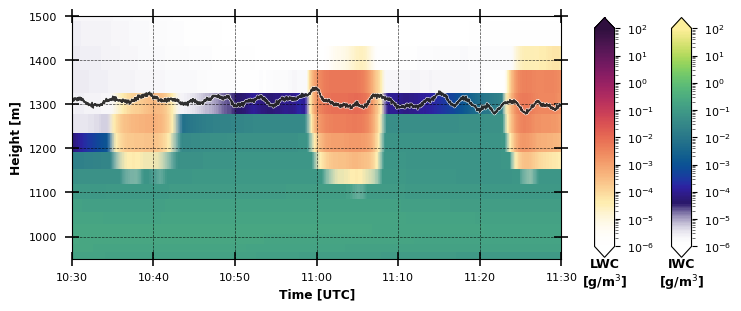

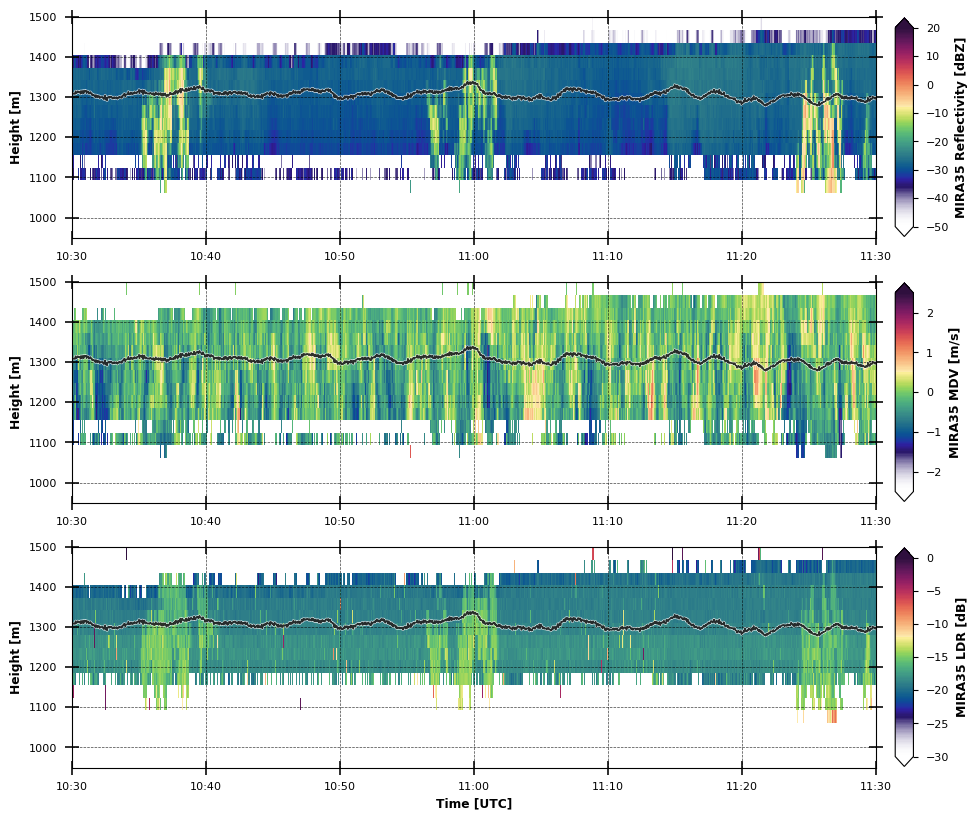

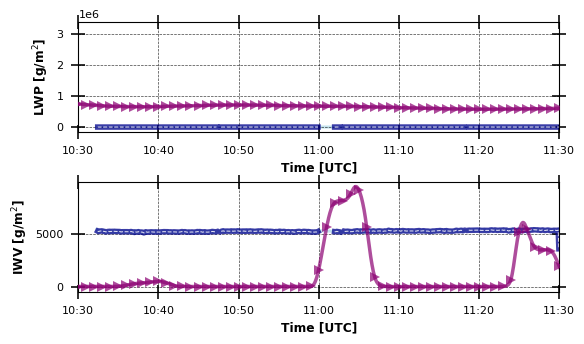

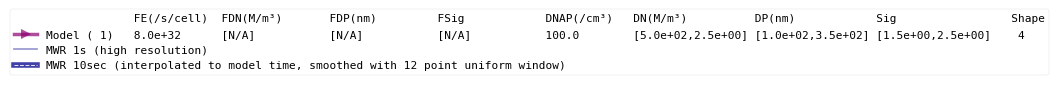

In [97]:
import matplotlib as mpl
importlib.reload(tools)

# import scienceplots 
# plt.style.use(["science", "no-latex"])
plt.style.use("seaborn-v0_8-paper")


colorbar_fontsize = 12
axis_label_fontsize = 12
colorbar_kwargs  = tools.KWM(ha='center', va='top', fontweight='semibold', fontsize=colorbar_fontsize)
text_kwargs = tools.KWM(fontdict={'weight': 'semibold', 'size': axis_label_fontsize})


date_str = '20230125'
date1 = date_str[:4] + '-' + date_str[4:6] + '-' + date_str[6:8]
plot_timeframe = [np.datetime64(f'{date1}T10:30:00'), 
                  np.datetime64(f'{date1}T11:40:00')]

origin_lon, origin_lat = 7.872991, 47.070522

cmap = tools.cmap_new_timeheight
font_size = 12
nrows = 3


def add_holimo_line(fig, ax):
    if isinstance(ax, mpl.axes.Axes):
        ax = [ax]
    for iax in ax:
        iax.plot(holimo_data['time'], holimo_data['instData_Height'], color='white', linestyle='-', linewidth=2.0, alpha=0.7)
        iax.plot(holimo_data['time'], holimo_data['instData_Height'], color='black', linestyle='-', linewidth=1.0, alpha=0.8)

def setup_axes(fig, axes):
    has_multiple_axes = isinstance(axes, np.ndarray)
    for i, ax in enumerate(axes.flatten() if has_multiple_axes else [axes]):
        ax.set(xlim=plot_time_frame, xlabel='Time [UTC]', title='')
        ax.xaxis.set_major_formatter(md.DateFormatter('%H:%M'))
        ax.tick_params(axis='x', width=1.15, length=10, pad=5)  # Increase width and length for x-axis tick lines
        ax.tick_params(axis='y', width=1.15, length=10)  # Increase width and length for y-axis tick lines
        ax.tick_params(axis='both', which='both', direction='inout', top=True, right=True)
        ax.grid(which='both', linestyle='--', alpha=0.75, linewidth=0.5, color='black')
        ax.grid(which='minor', linestyle='--', alpha=0.55, linewidth=0.25, color='black')
        ax.xaxis.label.set_weight('semibold')
        ax.yaxis.label.set_weight('semibold')

def setup_cbars(fig, ax, labels, pad=0.02, fontsize=12):
    cbars = [fig.colorbar(ax[i].get_children()[0], ax=ax[i], pad=pad, extend='both', shrink=0.99, aspect=12) for i in range(len(ax))]
    for i, cbar in enumerate(cbars):
        cbar.set_label(labels[i], **colorbar_kwargs(fontsize=fontsize-3))
        cbar.ax.xaxis.set_label_coords(0.5, -0.1)


def setup_axes_y_height(axes, ylabel, ylim):
    for ax in axes.flatten() if isinstance(axes, np.ndarray) else [axes]:
        ax.set(ylabel=ylabel, ylim=ylim)

def plot_timeheight_model(model_run, fig, ax, var_list, norm_list, factor=1., vmin=1.0e-8, fontsize=12, tick_label_fontsize=8):


    cmap_list = [tools.create_fade_cmap(cmaps.haline, n_fade=32), 
                 tools.create_fade_cmap(cmaps.matter, n_fade=32), ]
    
    pmeshs = [ax.pcolormesh(model_run.time, model_run.z, model_run[var_list[0]].T*factor, norm=norm_list[0], cmap=cmap_list[0], zorder=1),
              ax.pcolormesh(model_run.time, model_run.z, model_run[var_list[1]].T*factor, norm=norm_list[1], cmap=cmap_list[1], zorder=1.1)]
    cbars = [fig.colorbar(pmeshs[0], ax=ax, pad=0.01, extend='both', shrink=0.99, aspect=12),
             fig.colorbar(pmeshs[1], ax=ax, pad=0.01, extend='both', shrink=0.99, aspect=12)]
    
    # Set the tick position to the left side for the middle colorbar
    cbars[0].ax.yaxis.set_ticks_position('right')
    cbars[1].ax.yaxis.set_ticks_position('right')
    cbars[0].ax.text(0.52, 4e-1 * vmin, 'IWC\n[g/m$^3$]', **colorbar_kwargs(fontsize=fontsize-3))
    cbars[1].ax.text(0.52, 4e-1 * vmin, 'LWC\n[g/m$^3$]', **colorbar_kwargs(fontsize=fontsize-3))
    cbars[0].ax.tick_params(labelsize=tick_label_fontsize)
    cbars[1].ax.tick_params(labelsize=tick_label_fontsize)
    
    setup_axes(fig, ax)
    add_holimo_line(fig, ax)
    setup_axes_y_height(ax, 'Height [m]', plot_height_frame)

def plot_timeheight_radar(radar_data, fig, ax, radar_variables, cmap='jet'):
    # provide radar_variables as list of strings in order: ['reflectivity factor', 'mean Dopplervelocity']
    radar_data[radar_variables[0]].T.plot(ax=ax[0], cmap=cmap, vmin=-50, vmax=20, add_colorbar=False)
    radar_data[radar_variables[1]].T.plot(ax=ax[1], cmap=cmap, vmin=-2.5, vmax=2.5, add_colorbar=False)
    radar_data[radar_variables[2]].T.plot(ax=ax[2], cmap=cmap, vmin=-30., vmax=0, add_colorbar=False)
    setup_cbars(fig, ax, ['MIRA35 Reflectivity [dBZ]', 'MIRA35 MDV [m/s]', 'MIRA35 LDR [dB]'])
    setup_axes(fig, ax)
    ax[0].set_xlabel('')
    ax[1].set_xlabel('')
    add_holimo_line(fig, ax)
    setup_axes_y_height(ax, 'Height [m]', plot_height_frame)


def plot_lwp_iwv(fig, ax, mwr_data, mwr_data_interp, model_timeseries, ensemble_nrs, alpha=0.5, lw2=1, factor=1.0e3):

    # Plot the data without labels first
    line_colors = cmaps.hawaii(np.linspace(0, 1, len(ensemble_nrs)+1))
    markers = np.random.choice(['o', 's', 'D', 'v', '^', '<', '>', 'p', '*'], size=len(ensemble_nrs))

    style_dark = {'color': 'darkblue', 'alpha': 0.75, 'linewidth': 4.0}
    style_white = {'color': 'white', 'alpha': 0.85, 'linewidth': 0.75, 'linestyle': '--'}
    for i, (iax, var) in enumerate(zip(ax, ['lwp', 'iwv'])):
        # Plot original and rebinned data
        iax.plot(mwr_data.time, mwr_data[var]*factor, color='lightblue', linewidth=2.25, alpha=0.7, zorder=1)
        iax.plot(mwr_data_interp.time, mwr_data_interp[var]*factor, **style_dark, zorder=2)
        iax.plot(mwr_data_interp.time, mwr_data_interp[var]*factor, **style_white, zorder=2)
    
    
    #ax[0].plot(mwr_data['time'], mwr_data['lwp'], color='blue', label='MWR-LWP', alpha=alpha, linewidth=lw2)
    #ax[1].plot(mwr_data['time'], mwr_data['iwv'], color='blue', label='MWR-IWV', alpha=alpha, linewidth=lw2)
    ax[0].set(ylabel='LWP [g/m$^2$]')#, ylim=(25.0, 125.0))
    ax[1].set(ylabel='IWV [g/m$^2$]')#, ylim=(2.5, 7.5))

    lines_ensembles = []
    labels_ensembles = []
    for idx, (id, color, marker) in enumerate(zip(ensemble_nrs, line_colors, markers)):

        
        style = {
            'color': color,
            'alpha': 0.7,
            'linestyle': '-',
            'marker': marker,
            'lw': 2.5,
            'markevery': 12,
            'markersize': 7.,
            'zorder': 3
        }
        label = tools.format_model_label(metadata[id], f'Model ({idx+1:2d}) ')
        line = ax[0].plot(model_timeseries[id]['time'], model_timeseries[id]['lwp']*factor, label=label, **style)
        ax[1].plot(model_timeseries[id]['time'], model_timeseries[id]['iwp']*factor, **style)
        lines_ensembles.append(line)
        labels_ensembles.append(label)
    setup_axes(fig, ax)

    # Create lines for legend (only for ax1)
    lines_mwr = []
    lines_mwr.append(ax[0].plot([], [], color='darkblue', linewidth=1.25, alpha=0.4)[0])
    lines_mwr.append(ax[0].plot([], [], **style_dark)[0])
    lines_mwr.append(ax[0].plot([], [], **style_white)[0])

    lines_ensembles, labels_ensembles = ax[0].get_legend_handles_labels()
    lines_mwr = [(lines_mwr[0]), (lines_mwr[1], lines_mwr[2])]
    labels_mwr = ['MWR 1s (high resolution)', 'MWR 10sec (interpolated to model time, smoothed with 12 point uniform window)']

    # Return the lines and label for the legend
    return lines_ensembles + lines_mwr, labels_ensembles + labels_mwr



png_path = f'{plot_path}/003-Quicklook-Meteogram-Observations/'


fig_size_M = (7.3, 3.)
fig_size_R = (12.5, 9.75)
fig_size_H = (6.2, 3.5)

vmin, vmax = 1e-6, 1e2
norm_nw = colors.LogNorm(vmin=vmin, vmax=vmax)
norm_nf = colors.LogNorm(vmin=vmin, vmax=vmax)

lines, labels = [], []
figs, axs = [],[]
fig_model, ax_model = plt.subplots(nrows=1, figsize=fig_size_M, constrained_layout=True)
plot_timeheight_model(
    model_timeheight, 
    fig_model, 
    ax_model, 
    ['qc_timeheight', 'qi_timeheight'], 
    [norm_nw, norm_nf], 
    vmin=vmin, factor=factor
)
#fig.subplots_adjust(hspace=0.2)  # make space for colorbar
model_filename = f'{data_set}_{run_id}_model_nw_nf_timeheight.png'
fig_model.savefig(f'{png_path}/{model_filename}', dpi=300, bbox_inches='tight', pad_inches=0.1)


# fig, ax = plt.subplots(nrows=2, figsize=fig_size_R)
# plot_timeheight_radar(radar_data, ax, ['Z', 'v'])
# fig.subplots_adjust(hspace=0.1)  # make space for colorbar
# fig.savefig(f'{png_path}/radar_Z_mdv_timeheight.png', dpi=300, bbox_inches='tight', pad_inches=0.1)

fig_radar, ax_radar = plt.subplots(nrows=3, figsize=fig_size_R)
plot_timeheight_radar(radar_data, fig_radar, ax_radar, ['Z', 'mdv', 'ldr'], cmap=cmap)
fig_radar.subplots_adjust(hspace=0.2)  # make space for colorbar
radar_filename = f'radar_Z_mdv_interp_timeheight.png'
fig_radar.savefig(f'{png_path}/{radar_filename}', dpi=300, bbox_inches='tight', pad_inches=0.1)


fig_hatpro, ax_hatpro = plt.subplots(nrows=2, figsize=fig_size_H)
lines, labels = plot_lwp_iwv(fig_hatpro, ax_hatpro, mwr_data, mwr_data_interp, model_data_timeseries, ensemble_nrs, )
hatpro_filename = f'model_hatpo_lwp_iwv_timeseries.png'
fig_hatpro.subplots_adjust(hspace=0.45)  # make space for colorbar
fig_hatpro.savefig(f'{png_path}/{hatpro_filename}', dpi=300, bbox_inches='tight', pad_inches=0.1)

    
# Save legend separately (only need to do this once)
legend_files = []
legend_filename = f'{data_set}_meteogram_legend.png'
if not legend_files and lines and labels:
    figlegend, axlegend = tools.create_ensemble_legend(lines, labels)
    figlegend.savefig(f'{png_path}/{legend_filename}', dpi=400, bbox_inches='tight', pad_inches=0.1)
    legend_files.append(legend_filename)

try:
    fig_model.savefig(f'{plot_path}/tmp/3-{model_filename}', dpi=300)
    fig_radar.savefig(f'{plot_path}/tmp/3-{radar_filename}', dpi=300)
    fig_hatpro.savefig(f'{plot_path}/tmp/3-{hatpro_filename}', dpi=300)
    # Save legend separately (only need to do this once)
    legend_files = []
    if not legend_files:
        legend_filename = f'{plot_path}/tmp/3-{data_set}_meteogram_legend.png'
        figlegend.savefig(legend_filename, dpi=400, bbox_inches='tight', pad_inches=0.1)
        legend_files.append(legend_filename)

except:
    pass

# Meteogram vs. Observations plot utility below, first part: header (imports, global variables, functions, etc. and second part: plotting main functions and saving plots

In [21]:
# model33_data_path = f'/work/bb1262/user/schimmel/cosmo-specs-torch/cosmo-specs-runs/eriswil/ensemble_output/cs-eriswil__20250117_111628/3D_20250117111742.nc'
# model33 = xr.open_dataset(model33_data_path)
# model33['qi']

In [22]:
np.nanmin(radar_data['Z'].values)

np.float32(-66.665375)

In [23]:

# import xarray as xr
# import numpy as np
# import matplotlib.pyplot as plt
# import pyinterp
# import pyinterp.fill
# from scipy.interpolate import griddata

# n = 30
# x = xr.DataArray(np.linspace(0, 2 * np.pi, n), dims=["x"])
# y = xr.DataArray(np.linspace(0, 2 * np.pi, n), dims=["y"])
# z = np.sin(x) * xr.ones_like(y)

# mask = xr.DataArray(np.random.randint(0, 1 + 1, (n, n)).astype("bool"), dims=["x", "y"])
# kw = dict(add_colorbar=False)

# def _griddata(arr, xi, method: str):
#     ar1d = arr.ravel()
#     valid = np.isfinite(ar1d)
#     if valid.all():
#         return arr
#     return griddata(
#         points=tuple(x[valid] for x in xi),
#         values=ar1d[valid],
#         xi=xi,
#         method=method,
#         fill_value=np.nan,
#     ).reshape(arr.shape)


# def interpolate_na(da, dim, method="nearest", use_coordinates=True, keep_attrs=True):
#     # Create points only once.
#     if use_coordinates:
#         coords = [da.coords[d] for d in dim]
#     else:
#         coords = [np.arange(da.sizes[d]) for d in dim]

#     xi = tuple(x.ravel() for x in np.meshgrid(*coords, indexing="ij"))
#     arr = xr.apply_ufunc(
#         _griddata,
#         da,
#         input_core_dims=[dim],
#         output_core_dims=[dim],
#         output_dtypes=[da.dtype],
#         dask="parallelized",
#         vectorize=True,
#         keep_attrs=keep_attrs,
#         kwargs={"xi": xi, "method": method},
#     ).transpose(*da.dims)
#     return arr


# fig,ax = plt.subplots(1,3,figsize=(11,3))
# interpolate_na(z.where(mask), ["y", "x"], method="nearest").plot(ax=ax[0], **kw)
# interpolate_na(z.where(mask), ["y", "x"], method="linear").plot(ax=ax[1], **kw)
# interpolate_na(z.where(mask), ["y", "x"], method="cubic").plot(ax=ax[2], **kw)